<h1> 1. Scale-Free Network Modeling & Analysis

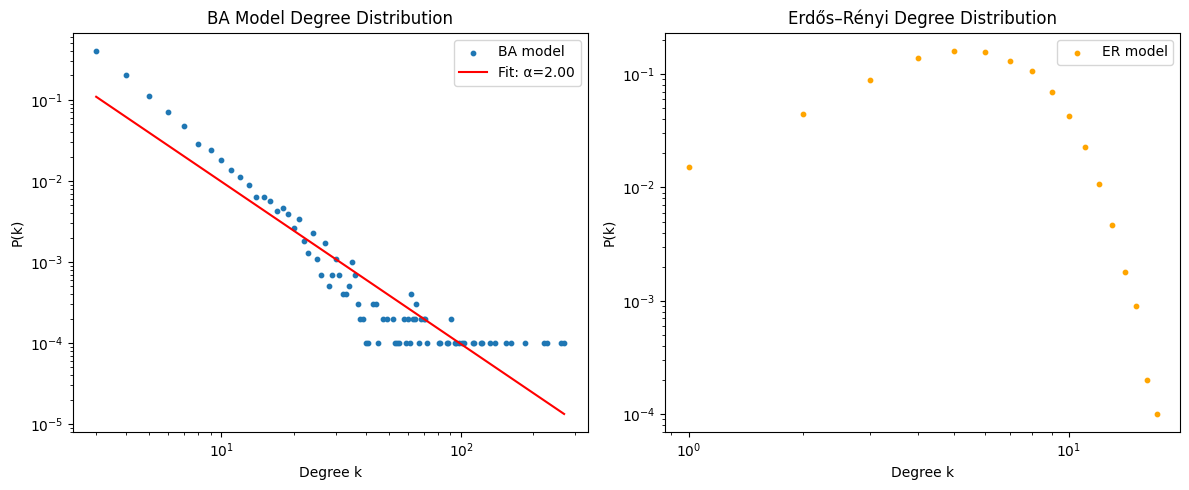

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def barabasi_albert(n, m0, m):
    # Start with a complete graph of m0 nodes
    G = nx.complete_graph(m0)
    # Each node appears as many times as its degree
    target_list = []
    for node in G.nodes():
        deg = G.degree(node)
        target_list += [node] * deg
    for new_node in range(m0, n):
        G.add_node(new_node)
        targets = set()
        while len(targets) < m:
            targets.add(random.choice(target_list))
        for t in targets:
            G.add_edge(new_node, t)
        target_list += [new_node] * m
        for t in targets:
            target_list.append(t)

    return G

# Parameters
n = 10000   # total nodes
m0 = 5      # initial clique size
m = 3       # edges to attach from new node

G_ba = barabasi_albert(n, m0, m)
p_er = (2 * m) / n
G_er = nx.erdos_renyi_graph(n, p_er)

def degree_distribution(G):
    degs = [d for _, d in G.degree()]
    max_deg = max(degs)
    hist, bins = np.histogram(degs, bins=range(max_deg + 2))
    pk = hist / hist.sum()
    ks = bins[:-1]
    return ks[pk > 0], pk[pk > 0]

k_ba, p_ba = degree_distribution(G_ba)
k_er, p_er = degree_distribution(G_er)

# Fit power law to BA tail: log–log linear fit for k >= m
mask = k_ba >= m
slope, intercept, r_value, p_value, std_err = stats.linregress(
    np.log(k_ba[mask]), np.log(p_ba[mask])
)
alpha = -slope


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(k_ba, p_ba, s=10, label='BA model')
plt.plot(k_ba[mask], np.exp(intercept) * k_ba[mask]**slope, 
         color='red', label=f'Fit: α={alpha:.2f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('BA Model Degree Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(k_er, p_er, s=10, color='orange', label='ER model')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Erdős–Rényi Degree Distribution')
plt.legend()
plt.tight_layout()
plt.show()


--------------------

First I implemented a Barabási–Albert (BA) network from scratch: it begins with a small clique of 𝑚0 nodes, then adds one new node at a time, each of which attaches to 𝑚 existing nodes chosen with probability proportional to their current degree (“preferential attachment”). Simultaneously, an Erdős–Rényi (ER) random graph is constructed on the same number of nodes n with link‐probability p=2m/n, so that both networks have roughly the same average degree. For each graph, it is computed for the empirical degree distribution P(k), bins it, and normalizes to get the fraction of nodes of each degree k. 

In the BA case, it then fits a straight line to the tail of the log–log plot of P(k) versus k, extracting the power‐law exponent α. Finally, the script plots both distributions on log–log axes side by side.

The resulting figure shows that the BA network’s degree distribution (blue points) falls off as a straight line on log–log axes, confirming a power‐law P(k)∝ k power −2 with exponent 𝛼 ≈ 2. In contrast, the ER network’s distribution (orange points) peaks sharply around its mean degree and decays much more rapidly, with no straight‐line tail—indicative of its Poisson‐like degree distribution. 

Thus, the code not only demonstrates how to generate and analyze both models, but also visually highlights the key difference: BA networks are scale‐free with heavy‐tailed degree distributions, whereas ER graphs exhibit exponentially bounded degree variability.

-------------------------------------------------------

<h1>2. Community Detection

Modularity Score: 0.8473


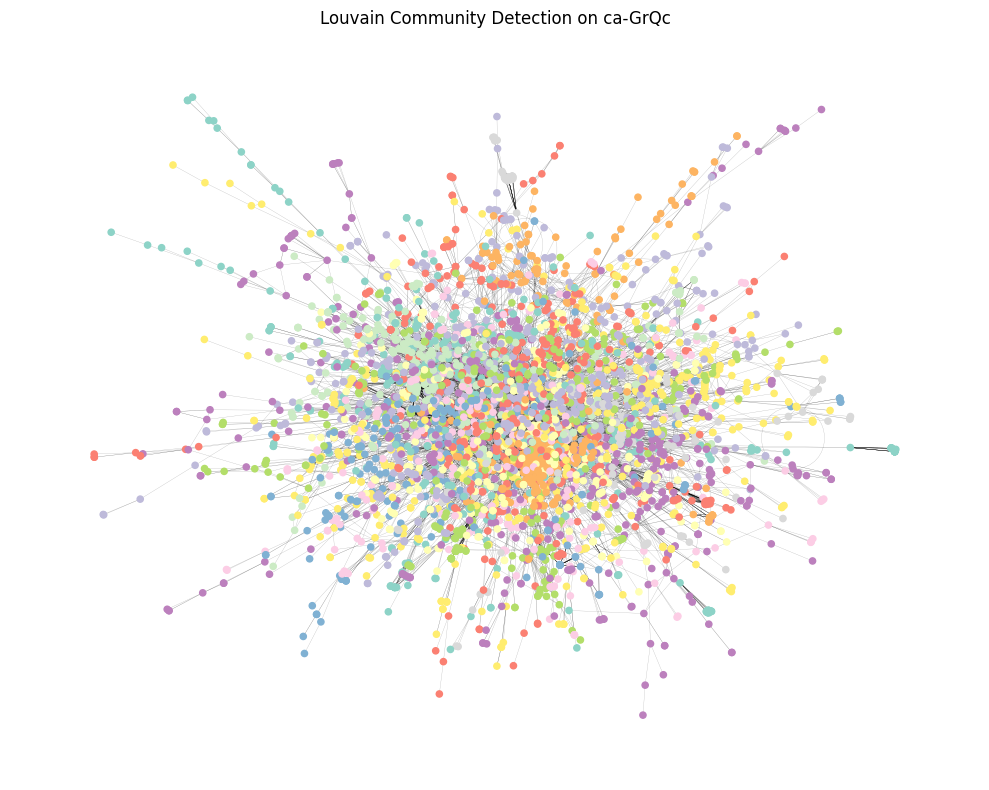

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain  

G = nx.read_edgelist("ca-GrQc.txt", comments='#', create_using=nx.Graph())
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
partition = community_louvain.best_partition(G)
modularity_score = community_louvain.modularity(partition, G)
print(f"Modularity Score: {modularity_score:.4f}")

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=20, cmap=plt.cm.Set3,
                       node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.2)
plt.title("Louvain Community Detection on ca-GrQc")
plt.axis('off')
plt.tight_layout()
plt.savefig("ca-GrQc_Louvain_Communities.png", dpi=300)
plt.show()


The center is densely packed, showing that many nodes (authors) are interconnected which is typical in a scientific collaboration network. Each unique color shows a community (a cluster of nodes more connected internally than with the rest of the network). The outer nodes are less connected, forming smaller satellite communities or acting as bridges.

Louvain optimizes modularity, so this structure shows a clear division of communities while preserving the overall connectedness of the graph.
The presence of many distinct color regions confirms the existence of multiple collaboration clusters (research groups or subfields).

----------------------------------------------

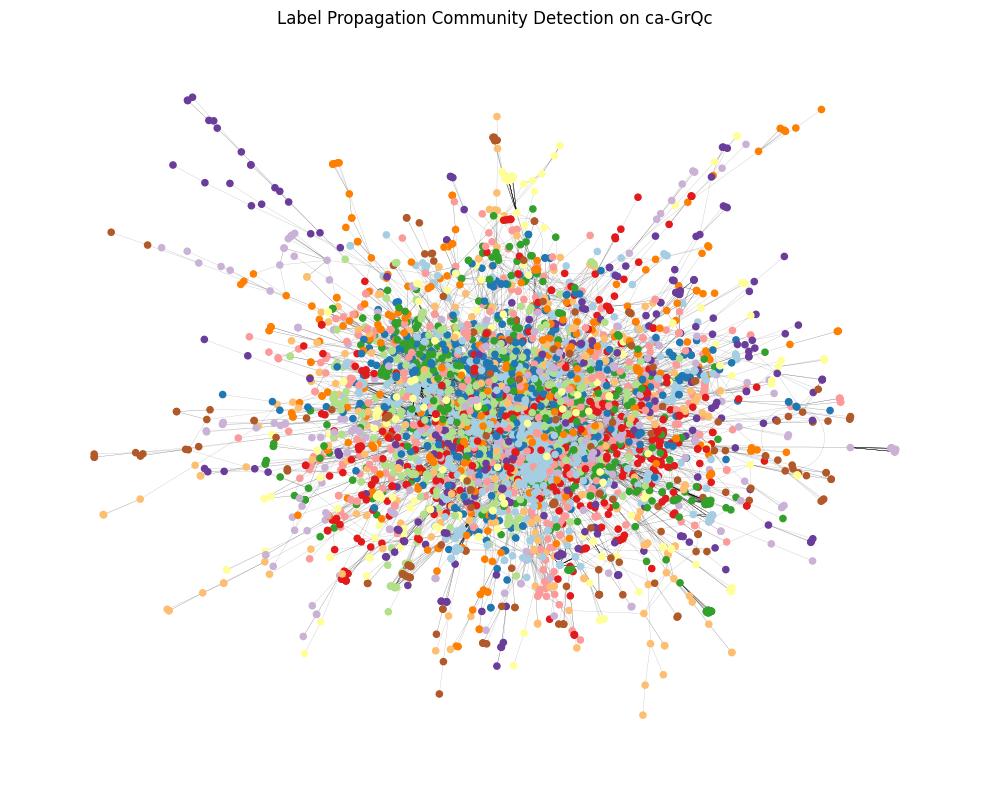

In [ ]:
from networkx.algorithms.community import label_propagation_communities

G = nx.read_edgelist("ca-GrQc.txt", comments='#', create_using=nx.Graph())
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

communities = label_propagation_communities(G)
partition = {node: i for i, community in enumerate(communities) for node in community}

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=20, cmap=plt.cm.Paired,
                       node_color=[partition[node] for node in G.nodes()])
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.2)
plt.title("Label Propagation Community Detection on ca-GrQc")
plt.axis('off')
plt.tight_layout()
plt.savefig("ca-GrQc_LabelPropagation_Communities.png", dpi=300)
plt.show()


Like the Louvain result, the center is densely connected, which reflects strong collaboration within the core network. The Label Propagation algorithm has produced a larger number of smaller communities, as seen by the higher diversity of node colors spread across the graph. Many outer nodes form isolated or peripheral communities which is a behavior often seen with label propagation due to its non-deterministic nature and local update rules.

Comparison with Louvain:

- Louvain: Fewer, more stable communities with higher modularity.

- Label Propagation: Faster and more distributed but less stable — results can vary across runs.

------------------------------------------------------------